# Real vs AI Image Forensic Analysis — paired img2img study

This notebook is designed for a **small paired experiment**: each real photograph has an img2img-generated counterpart.

It deliberately separates:
- **visual forensic transforms**: FFT/phase, DWT, DCT, residuals, contours/edges, LBP, GLCM, intensity/color, ELA;
- **quantitative features** extracted from those transforms;
- **paired statistics** comparing the 8 real images with their 8 AI counterparts.

### Important experimental rule
The real and AI images are treated as **paired semantic samples**, not pixel-aligned images. Therefore this notebook does **not** use raw pixel MSE/PSNR/SSIM as evidence of AI generation. Img2img can change geometry/content, so direct pixel differences would confound synthesis artifacts with ordinary image differences.

### Why these transforms?
Recent reviews classify spatial, frequency, residual/fingerprint and patch-based methods as major families of AI-image forensics. Fourier/DFT, DWT and DCT remain established frequency-domain tools, while residual + FFT approaches such as Synthbuster specifically target periodic artifacts from diffusion generation. Texture descriptors such as LBP/GLCM provide complementary spatial statistics.

**This notebook is an exploratory forensic analysis, not a validated AI detector. With n=8 pairs, conclusions should be presented as observations and effect sizes, not universal claims.**


## 0. Setup and package choices

The implementation uses current public APIs rather than the older `scipy.fftpack` interface.

Main libraries:
- NumPy
- SciPy (`scipy.fft.fft2`, `scipy.fft.dctn`)
- PyWavelets (`pywt.wavedec2`)
- scikit-image (`graycomatrix`, `graycoprops`, `local_binary_pattern`, entropy)
- OpenCV for image I/O, gradients and contours
- pandas/matplotlib for tables and figures

The notebook intentionally **does not call a "Contourlet approximation" a Contourlet Transform**, and it does not call a Dual-Tree Complex Wavelet Transform a Quaternion Wavelet Transform. Those are different transforms. For a minor project, it is scientifically cleaner to use the literal transforms you can implement and label them correctly.


In [1]:
# If your environment is missing packages, run this once in a terminal/notebook cell:
# %pip install -U numpy scipy pywavelets scikit-image opencv-python pandas matplotlib pillow

import io
import itertools
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from scipy.fft import fft2, fftshift, dctn
from scipy import stats
import pywt

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import shannon_entropy

np.set_printoptions(suppress=True, precision=5)

print("NumPy:", np.__version__)
print("SciPy:", __import__("scipy").__version__)
print("PyWavelets:", pywt.__version__)
print("scikit-image:", __import__("skimage").__version__)
print("OpenCV:", cv2.__version__)


NumPy: 2.5.1
SciPy: 1.18.0
PyWavelets: 1.8.0
scikit-image: 0.26.0
OpenCV: 5.0.0


## 1. Configuration and paired dataset loading

Expected structure:

```text
project/
├── analysis_proper.ipynb
├── real/
│   ├── books.jpg
│   ├── city.jpg
│   └── ...
└── ai/
    ├── books.jpg
    ├── city.jpg
    └── ...
```

Pairs are matched by filename stem. The loader checks for missing counterparts and duplicate stems, applies EXIF orientation, and preserves aspect ratio with a centered crop before resizing to the common analysis size. The original files are never overwritten.


In [2]:
REAL_DIR = Path("real")
AI_DIR = Path("ai")
OUT_DIR = Path("analysis_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# All transforms operate on a common analysis size.
# center_crop preserves aspect ratio instead of stretching the photograph.
ANALYSIS_SIZE = (512, 512)  # width, height
RESIZE_MODE = "center_crop"  # "center_crop" or "stretch"
SHOW_ALL_VISUALS = False
SAVE_ALL_PAIR_FIGURES = True


def index_images(folder):
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Dataset folder not found: {folder.resolve()}")
    if not folder.is_dir():
        raise NotADirectoryError(folder)

    index = {}
    duplicates = []
    for p in sorted(folder.iterdir()):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            key = p.stem.lower()
            if key in index:
                duplicates.append((key, index[key], p))
            else:
                index[key] = p
    if duplicates:
        names = ", ".join(k for k, _, _ in duplicates)
        raise RuntimeError(f"Duplicate filename stems in {folder}: {names}")
    return index


def find_pairs(real_dir=REAL_DIR, ai_dir=AI_DIR):
    real = index_images(real_dir)
    ai = index_images(ai_dir)
    common = sorted(set(real) & set(ai))

    missing_ai = sorted(set(real) - set(ai))
    missing_real = sorted(set(ai) - set(real))

    if missing_ai:
        print("Missing AI counterpart:", missing_ai)
    if missing_real:
        print("Missing real counterpart:", missing_real)

    pairs = [(stem, real[stem], ai[stem]) for stem in common]
    print(f"Matched pairs: {len(pairs)}")
    return pairs


pairs = find_pairs()


def load_rgb(path, size=ANALYSIS_SIZE, resize_mode=RESIZE_MODE):
    # exif_transpose prevents smartphone/camera orientation metadata from creating
    # artificial rotation differences between real and AI images.
    img = ImageOps.exif_transpose(Image.open(path)).convert("RGB")

    if resize_mode == "stretch":
        img = img.resize(size, Image.Resampling.LANCZOS)
    elif resize_mode == "center_crop":
        # Preserve aspect ratio, then take a centered crop of the target size.
        scale = max(size[0] / img.width, size[1] / img.height)
        new_size = (
            max(size[0], round(img.width * scale)),
            max(size[1], round(img.height * scale)),
        )
        img = img.resize(new_size, Image.Resampling.LANCZOS)
        left = (img.width - size[0]) // 2
        top = (img.height - size[1]) // 2
        img = img.crop((left, top, left + size[0], top + size[1]))
    else:
        raise ValueError("resize_mode must be 'center_crop' or 'stretch'")

    return np.asarray(img, dtype=np.float32) / 255.0


def rgb_to_gray(rgb):
    return (
        0.299 * rgb[..., 0] +
        0.587 * rgb[..., 1] +
        0.114 * rgb[..., 2]
    ).astype(np.float32)


def load_pair(stem, real_path, ai_path):
    r = load_rgb(real_path)
    a = load_rgb(ai_path)
    return r, a, rgb_to_gray(r), rgb_to_gray(a)


if len(pairs) == 0:
    raise RuntimeError("No matched pairs found. Check the real/ and ai/ folders.")


Matched pairs: 8


# 2. FFT / Fourier analysis

A 2-D FFT represents the image as spatial frequencies. The notebook reports:

1. log-magnitude spectrum;
2. phase spectrum;
3. normalized radial power spectrum;
4. low/mid/high-frequency energy ratios;
5. a high-frequency residual spectrum.

A raw FFT picture is not enough for a scientific comparison, so the radial spectrum and frequency-band energy are also saved numerically.

**Important:** frequency artifacts are generator-dependent. The correct statement is that this experiment tests whether your particular img2img pipeline leaves measurable spectral differences, not that all AI images have one universal FFT signature.


**Implementation note:** radial FFT power is now computed by summing power inside each annulus before normalization, so annuli are not biased by their pixel counts.


In [3]:
def _frequency_radius(shape):
    h, w = shape
    fy = np.fft.fftshift(np.fft.fftfreq(h))
    fx = np.fft.fftshift(np.fft.fftfreq(w))
    yy, xx = np.meshgrid(fy, fx, indexing="ij")
    # Normalize radius so the corners are approximately 1.
    max_radius = np.sqrt(0.5**2 + 0.5**2)
    return np.sqrt(xx**2 + yy**2) / max_radius


def fft_features(gray):
    x = gray - gray.mean()
    F = fftshift(fft2(x, norm="ortho"))
    mag = np.abs(F)
    logmag = np.log1p(mag)
    phase = np.angle(F)

    power = mag ** 2
    rr = _frequency_radius(gray.shape)

    # Correct radial power: sum power in each annulus, then normalize by total power.
    # The previous version averaged each annulus and then normalized those means,
    # which over-weighted sparse high-frequency bins.
    bins = np.linspace(0, 1, 160)
    radial = np.full(len(bins) - 1, np.nan, dtype=np.float64)
    for i in range(len(radial)):
        mask = (rr >= bins[i]) & (rr < bins[i + 1])
        if np.any(mask):
            radial[i] = power[mask].sum()
    total = power.sum() + 1e-12
    radial_norm = np.nan_to_num(radial / total, nan=0.0)

    # These cutoffs are normalized analysis choices, not physical constants.
    low = rr < 0.20
    mid = (rr >= 0.20) & (rr < 0.50)
    high = rr >= 0.50

    return {
        "logmag": logmag,
        "phase": phase,
        "radial": radial_norm,
        "radial_r": (bins[:-1] + bins[1:]) / 2,
        "low_freq_ratio": float(power[low].sum() / total),
        "mid_freq_ratio": float(power[mid].sum() / total),
        "high_freq_ratio": float(power[high].sum() / total),
        "spectral_centroid": float((rr * power).sum() / total),
    }


def plot_fft_pair(stem, rg, ag, show=True):
    R, A = fft_features(rg), fft_features(ag)
    fig, ax = plt.subplots(2, 3, figsize=(15, 9))
    ax[0,0].imshow(rg, cmap="gray"); ax[0,0].set_title("Real — grayscale")
    ax[0,1].imshow(R["logmag"], cmap="magma"); ax[0,1].set_title("Real — FFT log magnitude")
    ax[0,2].imshow(R["phase"], cmap="twilight", vmin=-np.pi, vmax=np.pi); ax[0,2].set_title("Real — FFT phase")
    ax[1,0].imshow(ag, cmap="gray"); ax[1,0].set_title("AI — grayscale")
    ax[1,1].imshow(A["logmag"], cmap="magma"); ax[1,1].set_title("AI — FFT log magnitude")
    ax[1,2].imshow(A["phase"], cmap="twilight", vmin=-np.pi, vmax=np.pi); ax[1,2].set_title("AI — FFT phase")
    for a in ax.ravel(): a.axis("off")
    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_fft_phase.png", dpi=160, bbox_inches="tight")

    if show:
        plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(R["radial_r"], R["radial"] + 1e-14, label="Real")
    ax.semilogy(A["radial_r"], A["radial"] + 1e-14, label="AI")
    ax.set_xlabel("Normalized radial frequency")
    ax.set_ylabel("Fraction of total power")
    ax.set_title(f"{stem} — radial power spectrum")
    ax.legend(); ax.grid(alpha=0.25)
    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_fft_radial.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    return R, A


# 3. DWT — multilevel spatial-frequency analysis

DWT is more informative than FFT when the artifact is localized because it provides both scale and spatial localization.

We use a 3-level 2-D Haar decomposition and report:
- LL approximation energy;
- LH, HL, HH detail energy at each level;
- normalized detail-energy ratios;
- detail entropy.

PyWavelets documents `wavedec2`/2-D multilevel decomposition and the approximation/detail coefficient structure.


In [4]:
def safe_entropy(x, bins=256):
    x = np.asarray(x, dtype=np.float64)
    hist, _ = np.histogram(x.ravel(), bins=bins, density=False)
    p = hist / max(hist.sum(), 1)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

def dwt_features(gray, wavelet="haar", level=3):
    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level, mode="symmetric")
    # coeffs = [LL_n, (LH_n, HL_n, HH_n), ..., (LH_1, HL_1, HH_1)]
    out = {}
    for i, item in enumerate(coeffs):
        if i == 0:
            band = item
            out[f"LL{level}_energy"] = float(np.mean(band**2))
            out[f"LL{level}_entropy"] = safe_entropy(band)
        else:
            lev = level - i + 1
            lh, hl, hh = item
            for name, band in zip(("LH","HL","HH"), (lh,hl,hh)):
                out[f"{name}{lev}_energy"] = float(np.mean(band**2))
                out[f"{name}{lev}_absmean"] = float(np.mean(np.abs(band)))
                out[f"{name}{lev}_entropy"] = safe_entropy(band)

    total = sum(v for k,v in out.items() if k.endswith("_energy"))
    out["detail_energy_ratio"] = float(
        sum(v for k,v in out.items() if "_energy" in k and not k.startswith("LL"))
        / (total + 1e-12)
    )
    return out, coeffs

def plot_dwt_pair(stem, rg, ag, show=True):
    rf, rc = dwt_features(rg)
    af, ac = dwt_features(ag)

    # Show level-1 details because they are easiest to interpret visually.
    r_lh, r_hl, r_hh = rc[-1]
    a_lh, a_hl, a_hh = ac[-1]

    fig, ax = plt.subplots(2, 4, figsize=(15, 7))
    for j, (img, title) in enumerate([
        (rg, "Real"),
        (r_lh, "Real LH"),
        (r_hl, "Real HL"),
        (r_hh, "Real HH")
    ]):
        ax[0,j].imshow(img, cmap="gray")
        ax[0,j].set_title(title)
        ax[0,j].axis("off")

    for j, (img, title) in enumerate([
        (ag, "AI"),
        (a_lh, "AI LH"),
        (a_hl, "AI HL"),
        (a_hh, "AI HH")
    ]):
        ax[1,j].imshow(img, cmap="gray")
        ax[1,j].set_title(title)
        ax[1,j].axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_dwt.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    return rf, af


# 4. DCT — block frequency energy

DCT is especially relevant to image-compression statistics. We use **8×8 blocks**, compute an orthonormal 2-D DCT for each block, and report:

- DC energy;
- low-frequency AC energy;
- high-frequency AC energy;
- high-frequency AC / total AC ratio.

This is preferable to simply averaging arbitrary DCT coefficients. SciPy's current `scipy.fft.dct`/`dctn` API is used instead of the legacy `scipy.fftpack`.


**Implementation note:** DC energy is calculated from the uncentered block. AC-frequency ratios are calculated separately from a mean-centered block. This avoids the previous bug where subtracting the block mean forced the DC coefficient to approximately zero.


In [5]:
def block_dct_features(gray, block=8):
    h, w = gray.shape
    h -= h % block
    w -= w % block
    x = gray[:h, :w]

    hf_ratios = []
    dc_ratios = []
    coeff_accum = []

    yy, xx = np.indices((block, block))
    hf_mask = (yy + xx) >= block
    lf_mask = (yy + xx) <= 3
    ac_mask = np.ones((block, block), dtype=bool)
    ac_mask[0, 0] = False

    for y in range(0, h, block):
        for x0 in range(0, w, block):
            b = x[y:y+block, x0:x0+block]

            # IMPORTANT: do not subtract the mean before measuring DC energy.
            # The old code did so, making dct_dc_ratio_mean ~ 0 by construction.
            c_raw = dctn(b, type=2, norm="ortho")
            e_raw = c_raw ** 2
            total_raw = e_raw.sum() + 1e-12
            dc_ratios.append(float(e_raw[0, 0] / total_raw))

            # Centered DCT is used for AC-frequency statistics.
            c = dctn(b - b.mean(), type=2, norm="ortho")
            e = c ** 2
            total_ac = e[ac_mask].sum() + 1e-12
            hf_ratios.append(float(e[hf_mask].sum() / total_ac))
            coeff_accum.append(np.abs(c))

    coeff_accum = np.mean(coeff_accum, axis=0)

    return {
        "dct_dc_ratio_mean": float(np.mean(dc_ratios)),
        "dct_highfreq_ratio_mean": float(np.mean(hf_ratios)),
        "dct_coeff_abs_mean": float(coeff_accum.mean()),
        "dct_highfreq_abs_mean": float(coeff_accum[hf_mask].mean()),
        "dct_lowfreq_abs_mean": float(coeff_accum[lf_mask].mean()),
        "dct_coeff_map": coeff_accum,
    }


def plot_dct_pair(stem, rg, ag, show=True):
    R, A = block_dct_features(rg), block_dct_features(ag)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(np.log1p(R["dct_coeff_map"]), cmap="viridis")
    ax[0].set_title("Real — mean |8×8 centered DCT|")
    ax[1].imshow(np.log1p(A["dct_coeff_map"]), cmap="viridis")
    ax[1].set_title("AI — mean |8×8 centered DCT|")
    for a in ax: a.axis("off")
    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_dct.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    return R, A


# 5. Residual / fingerprint analysis

We use two residual analyses:

**A. Gaussian high-pass residual**

`R = I - GaussianBlur(I)`

**B. Absolute cross-difference residual**

`C(x,y) = |I(x,y) + I(x+1,y+1) - I(x+1,y) - I(x,y+1)|`

The cross-difference is a high-pass filter used in image forensics. Synthbuster applies this idea before Fourier analysis and examines periodic frequency components associated with diffusion-model artifacts. The updated notebook therefore also extracts a compact set of period-2/4/8 FFT peak features from each RGB channel. It is explicitly described as **Synthbuster-inspired**, not as a reproduction of its full 135-dimensional classifier.

The scalar outputs include residual statistics, high-frequency energy and periodic FFT peak magnitudes.


In [6]:
def cross_difference(img):
    """Absolute 2x2 diagonal cross-difference, matching the forensic filter definition."""
    return np.abs(
        img[:-1, :-1] +
        img[1:, 1:] -
        img[1:, :-1] -
        img[:-1, 1:]
    )


def synthbuster_peak_features(rgb, periods=(2, 4, 8)):
    """Extract simplified periodic FFT peaks inspired by Synthbuster.

    This is NOT a reproduction of the paper's full 135-dimensional classifier.
    It extracts FFT magnitudes near period-related frequencies for each RGB
    channel after cross-difference filtering.

    Important implementation detail:
    cross_difference() reduces an HxW image to (H-1)x(W-1). Therefore the FFT
    dimensions must be taken from the residual itself, not from the original RGB
    image. Using the original dimensions can produce an out-of-bounds index for
    p=2 (e.g. index 511 for a 511x511 residual).
    """
    out = {}

    for ch, name in enumerate(("r", "g", "b")):
        residual = cross_difference(rgb[..., ch])
        rh, rw = residual.shape

        F = fftshift(fft2(residual, norm="ortho"))
        mag = np.abs(F)
        cy, cx = rh // 2, rw // 2

        for p in periods:
            # Nearest available FFT-bin offset for the requested spatial period.
            # For an odd-sized residual (e.g. 511x511), p=2 maps to the edge
            # frequency bin without exceeding the valid array bounds.
            ky = min(max(1, round(rh / p)), rh // 2)
            kx = min(max(1, round(rw / p)), rw // 2)

            offsets = {
                "x": [(0, kx), (0, -kx)],
                "y": [(ky, 0), (-ky, 0)],
                "d": [(ky, kx), (ky, -kx), (-ky, kx), (-ky, -kx)],
            }

            for direction, pairs_ in offsets.items():
                vals = []
                for dy, dx in pairs_:
                    yy = cy + dy
                    xx = cx + dx
                    # Defensive bounds check. No clipping to an edge value is
                    # used, because clipping could silently duplicate a peak.
                    if 0 <= yy < rh and 0 <= xx < rw:
                        vals.append(mag[yy, xx])

                out[f"synth_{name}_p{p}_{direction}_mean"] = (
                    float(np.mean(vals)) if vals else np.nan
                )

        total = mag.sum() + 1e-12
        rr = _frequency_radius(residual.shape)
        out[f"synth_{name}_fft_highfreq_ratio"] = float(
            mag[rr >= 0.50].sum() / total
        )

    return out


def residual_features(rgb, gray):
    blur = cv2.GaussianBlur(gray, (0, 0), sigmaX=1.0)
    hp = gray - blur

    # Grayscale aggregate for visualization/statistics.
    cd = cross_difference(rgb)
    cd_gray = rgb_to_gray(cd)

    F = fftshift(fft2(cd_gray - cd_gray.mean(), norm="ortho"))
    power = np.abs(F) ** 2
    rr = _frequency_radius(cd_gray.shape)
    total = power.sum() + 1e-12

    out = {
        "hp_std": float(np.std(hp)),
        "hp_absmean": float(np.mean(np.abs(hp))),
        "hp_kurtosis": float(stats.kurtosis(hp.ravel(), fisher=True, bias=False)),
        "crossdiff_std": float(np.std(cd_gray)),
        "crossdiff_absmean": float(np.mean(np.abs(cd_gray))),
        "crossdiff_fft_highfreq_ratio": float(power[rr >= 0.50].sum() / total),
        "hp_map": hp,
        "crossdiff_map": cd_gray,
        "crossdiff_fft": np.log1p(np.abs(F)),
    }
    out.update(synthbuster_peak_features(rgb))
    return out


def plot_residual_pair(stem, r_rgb, a_rgb, rg, ag, show=True):
    R = residual_features(r_rgb, rg)
    A = residual_features(a_rgb, ag)
    fig, ax = plt.subplots(2, 3, figsize=(14, 8))
    for row, data, label in [(0, R, "Real"), (1, A, "AI")]:
        ax[row,0].imshow(data["hp_map"], cmap="gray")
        ax[row,0].set_title(f"{label} — Gaussian residual")
        ax[row,1].imshow(data["crossdiff_map"], cmap="gray")
        ax[row,1].set_title(f"{label} — cross-difference")
        ax[row,2].imshow(data["crossdiff_fft"], cmap="magma")
        ax[row,2].set_title(f"{label} — cross-diff FFT")
        for j in range(3): ax[row,j].axis("off")
    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_residuals.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    return R, A


# 6. Edge, gradient and contour analysis

"Contour analysis" is implemented literally here as an edge/contour analysis, not as a Contourlet transform.

We calculate:
- Sobel gradient magnitude;
- Laplacian absolute response;
- Canny edge density;
- contour count;
- total contour perimeter normalized by image area.

These are spatial-domain indicators. They should be interpreted together with frequency/residual features because natural texture can also create strong edges.


In [7]:
def edge_contour_features(gray):
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad = np.sqrt(gx**2 + gy**2)

    lap = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
    edges = cv2.Canny(np.clip(gray*255,0,255).astype(np.uint8), 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    perimeter = sum(cv2.arcLength(c, closed=True) for c in contours)

    return {
        "gradient_mean": float(grad.mean()),
        "gradient_std": float(grad.std()),
        "gradient_p95": float(np.percentile(grad,95)),
        "laplacian_absmean": float(np.mean(np.abs(lap))),
        "laplacian_std": float(lap.std()),
        "edge_density": float(np.mean(edges > 0)),
        "contour_count": int(len(contours)),
        "contour_perimeter_per_area": float(perimeter / gray.size),
        "gradient_map": grad,
        "laplacian_map": np.abs(lap),
        "edge_map": edges,
    }

def plot_edges_pair(stem, rg, ag, show=True):
    R, A = edge_contour_features(rg), edge_contour_features(ag)

    fig, ax = plt.subplots(2, 3, figsize=(14, 8))
    for row, data, label in [(0,R,"Real"), (1,A,"AI")]:
        ax[row,0].imshow(data["gradient_map"], cmap="magma")
        ax[row,0].set_title(f"{label} — gradient magnitude")
        ax[row,1].imshow(data["laplacian_map"], cmap="magma")
        ax[row,1].set_title(f"{label} — |Laplacian|")
        ax[row,2].imshow(data["edge_map"], cmap="gray")
        ax[row,2].set_title(f"{label} — Canny contours")
        for j in range(3): ax[row,j].axis("off")
    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_edges_contours.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    return R, A


# 7. LBP texture analysis

Local Binary Pattern captures local microtexture. We use the documented integer-image interface and the `uniform` variant.

The numerical feature is the normalized LBP histogram plus:
- histogram entropy;
- dominant-bin probability.

This is particularly relevant to your fabric, fur, wood and patterned-surface photographs.


In [8]:
def lbp_features(gray, P=8, R=1):
    # scikit-image recommends integer input for LBP.
    g = np.clip(gray*255, 0, 255).astype(np.uint8)
    lbp = local_binary_pattern(g, P, R, method="uniform")

    n_bins = P + 2
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(n_bins+1), density=False)
    hist = hist.astype(np.float64)
    hist /= hist.sum() + 1e-12

    return {
        "lbp_hist_entropy": float(-(hist[hist>0] * np.log2(hist[hist>0])).sum()),
        "lbp_dominant_bin": float(hist.max()),
        "lbp_mean_code": float(lbp.mean()),
        "lbp_std_code": float(lbp.std()),
        "lbp_map": lbp,
        "lbp_hist": hist,
    }

def plot_lbp_pair(stem, rg, ag, show=True):
    R, A = lbp_features(rg), lbp_features(ag)

    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    ax[0,0].imshow(R["lbp_map"], cmap="viridis"); ax[0,0].set_title("Real — LBP")
    ax[1,0].imshow(A["lbp_map"], cmap="viridis"); ax[1,0].set_title("AI — LBP")
    ax[0,1].plot(R["lbp_hist"], marker="o", label="Real")
    ax[0,1].plot(A["lbp_hist"], marker="o", label="AI")
    ax[0,1].set_title("LBP histogram"); ax[0,1].legend()
    ax[1,1].bar(np.arange(len(R["lbp_hist"]))-0.18, R["lbp_hist"], width=0.36, label="Real")
    ax[1,1].bar(np.arange(len(A["lbp_hist"]))+0.18, A["lbp_hist"], width=0.36, label="AI")
    ax[1,1].set_title("LBP histogram comparison"); ax[1,1].legend()
    for a in ax.ravel(): a.axis("off") if a in [ax[0,0],ax[1,0]] else None
    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_lbp.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    return R, A


# 8. GLCM texture statistics

The original notebook used only distance=1 and angle=0. That is too narrow for a texture study.

We use:
- distances = 1, 2, 4 pixels;
- angles = 0°, 45°, 90°, 135°;
- 32 gray levels to keep the co-occurrence matrix compact.

For each property we average over distances and orientations:
- contrast
- dissimilarity
- homogeneity
- ASM
- energy
- correlation
- entropy

These are texture statistics, not direct evidence of AI generation.


In [9]:
def glcm_features(gray, levels=32):
    g = np.floor(np.clip(gray,0,1) * levels).astype(np.uint8)
    g[g >= levels] = levels - 1

    distances = [1, 2, 4]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    glcm = graycomatrix(
        g,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True
    )

    props = [
        "contrast", "dissimilarity", "homogeneity",
        "ASM", "energy", "correlation"
    ]

    out = {}
    for p in props:
        vals = graycoprops(glcm, p)
        out[f"glcm_{p}_mean"] = float(vals.mean())
        out[f"glcm_{p}_std"] = float(vals.std())

    # Entropy is computed directly from each normalized GLCM.
    ent = -np.sum(glcm * np.log2(glcm + 1e-12), axis=(0,1))
    out["glcm_entropy_mean"] = float(ent.mean())
    out["glcm_entropy_std"] = float(ent.std())
    return out, glcm


# 9. Intensity, color and entropy analysis

These are baseline statistics. They are useful because they reveal whether an img2img model changed:
- brightness/contrast;
- RGB channel distributions;
- saturation;
- image entropy.

Again, these are not expected to be universal AI signatures; they are controls and descriptive features.


In [10]:
def intensity_color_features(rgb, gray):
    out = {
        "intensity_mean": float(gray.mean()),
        "intensity_std": float(gray.std()),
        "intensity_p01": float(np.percentile(gray,1)),
        "intensity_p50": float(np.percentile(gray,50)),
        "intensity_p99": float(np.percentile(gray,99)),
        "intensity_entropy": float(shannon_entropy(np.clip(gray*255,0,255).astype(np.uint8))),
    }

    channels = ["r","g","b"]
    for i, c in enumerate(channels):
        out[f"{c}_mean"] = float(rgb[...,i].mean())
        out[f"{c}_std"] = float(rgb[...,i].std())
        out[f"{c}_entropy"] = float(shannon_entropy(np.clip(rgb[...,i]*255,0,255).astype(np.uint8)))

    # RGB correlations
    flat = rgb.reshape(-1,3)
    corr = np.corrcoef(flat.T)
    out["rgb_corr_rg"] = float(corr[0,1])
    out["rgb_corr_rb"] = float(corr[0,2])
    out["rgb_corr_gb"] = float(corr[1,2])

    # HSV statistics
    hsv = cv2.cvtColor(np.clip(rgb*255,0,255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    out["hsv_saturation_mean"] = float(hsv[...,1].mean()/255)
    out["hsv_value_mean"] = float(hsv[...,2].mean()/255)
    out["hsv_saturation_std"] = float(hsv[...,1].std()/255)
    return out

def plot_intensity_pair(stem, r_rgb, a_rgb, rg, ag, show=True):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].hist(rg.ravel(), bins=64, density=True, alpha=0.6, label="Real")
    ax[0].hist(ag.ravel(), bins=64, density=True, alpha=0.6, label="AI")
    ax[0].set_title("Grayscale intensity distribution")
    ax[0].set_xlabel("Normalized intensity"); ax[0].legend()

    for i, c in enumerate(["R","G","B"]):
        ax[1].hist(r_rgb[...,i].ravel(), bins=64, density=True, alpha=0.4, label=f"Real {c}")
        ax[1].hist(a_rgb[...,i].ravel(), bins=64, density=True, histtype="step", linewidth=1.5, label=f"AI {c}")
    ax[1].set_title("RGB distributions")
    ax[1].legend(ncol=2, fontsize=8)
    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_intensity_color.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


# 10. Error Level Analysis (ELA) — compression diagnostic

ELA recompresses an image as JPEG and measures the pixel difference. It is **not an AI detector**.

The updated implementation performs ELA on the **original file before the 512×512 analysis resize**, because resizing would otherwise erase much of the original compression history. Scalar ELA values therefore remain tied to the source file, while only the displayed ELA map is resized for side-by-side viewing.

ELA should remain a supporting compression/editing forensic diagnostic. If the real and AI files have different formats, save histories, or JPEG qualities, ELA may primarily reflect those differences.


In [11]:
def ela_features_from_path(path, quality=90, map_size=ANALYSIS_SIZE):
    """ELA on the original file, before analysis resizing.

    This preserves the image's original compression history as much as possible.
    ELA remains only a compression/editing diagnostic, not an AI detector.
    """
    img = ImageOps.exif_transpose(Image.open(path)).convert("RGB")
    arr = np.asarray(img, dtype=np.uint8)

    buf = io.BytesIO()
    Image.fromarray(arr, mode="RGB").save(buf, format="JPEG", quality=quality, subsampling=0)
    buf.seek(0)
    rec = np.asarray(Image.open(buf).convert("RGB"), dtype=np.float32)

    diff = np.abs(arr.astype(np.float32) - rec)
    diff_map = diff.mean(axis=2)

    # Resize only the visualization map; scalar features remain original-resolution.
    map_img = Image.fromarray(np.clip(diff_map, 0, 255).astype(np.uint8), mode="L")
    map_img = map_img.resize(map_size, Image.Resampling.BILINEAR)
    ela_map = np.asarray(map_img, dtype=np.float32) / 255.0

    return {
        "ela_mean": float(diff.mean() / 255),
        "ela_std": float(diff.std() / 255),
        "ela_p95": float(np.percentile(diff, 95) / 255),
        "ela_max": float(diff.max() / 255),
        "ela_map": ela_map,
    }


def plot_ela_pair(stem, R, A, show=True):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    vmax = max(R["ela_map"].max(), A["ela_map"].max()) + 1e-12
    ax[0].imshow(R["ela_map"], cmap="inferno", vmin=0, vmax=vmax)
    ax[0].set_title("Real — ELA")
    ax[1].imshow(A["ela_map"], cmap="inferno", vmin=0, vmax=vmax)
    ax[1].set_title("AI — ELA")
    for a in ax: a.axis("off")
    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_ela.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    return R, A


# 11. Run every analysis on every pair

For each image we store:
- scalar forensic features in a long-format table;
- visual transforms for every pair;
- no direct pixel-difference metric.

The first pair is displayed inline as a representative example; all pair figures are saved to `analysis_outputs/`.


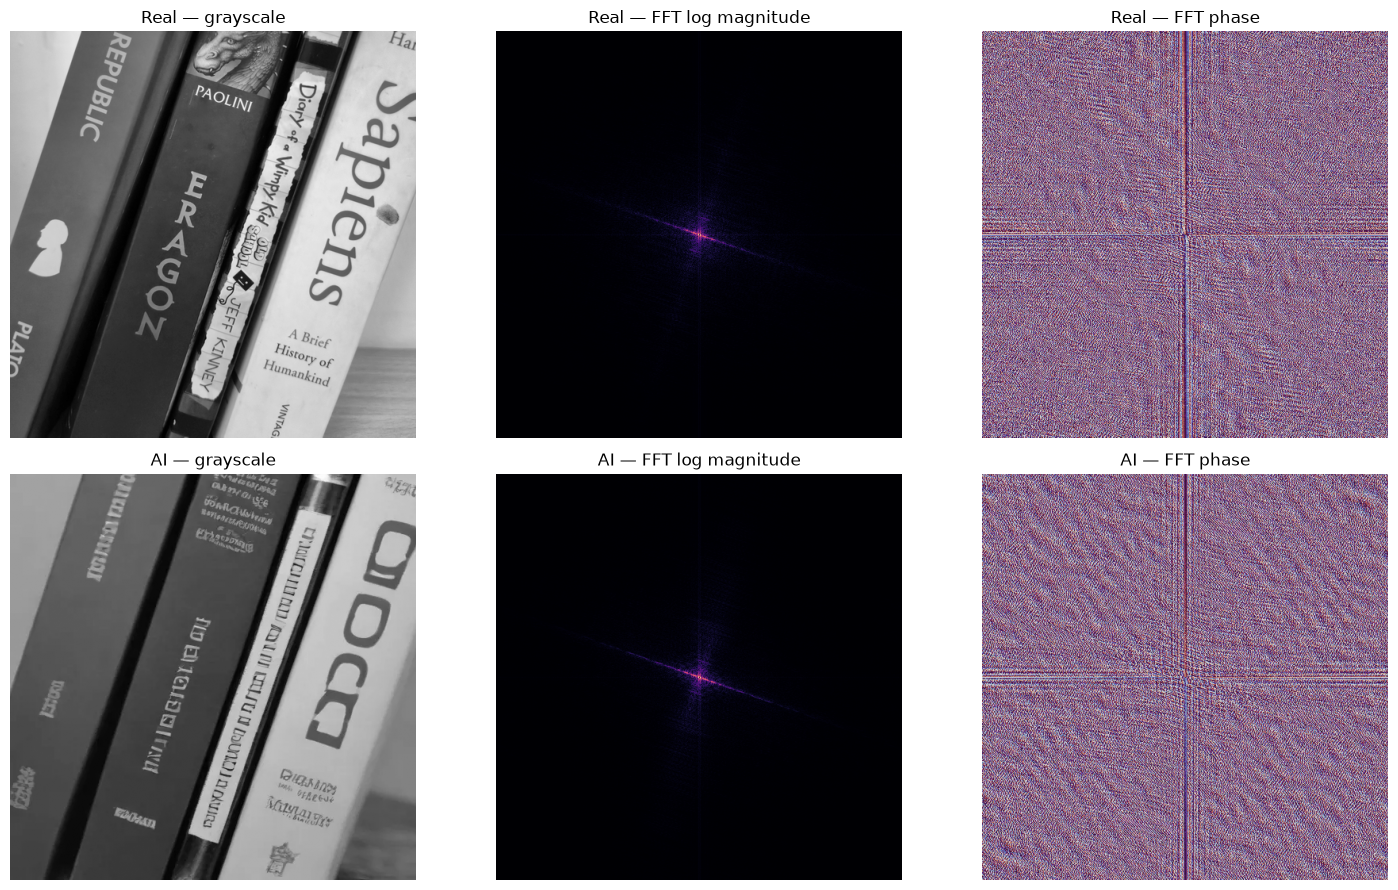

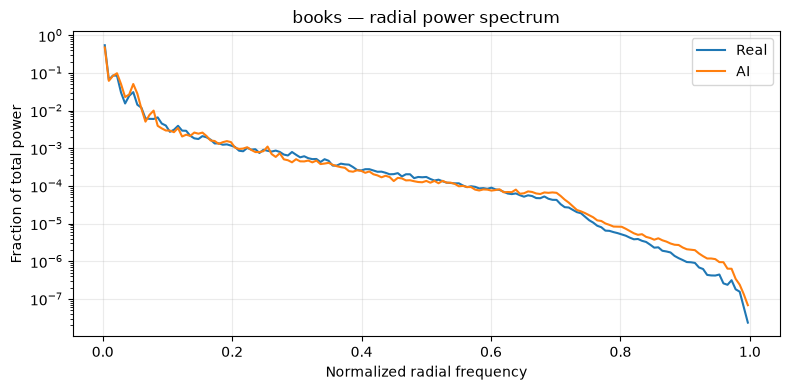

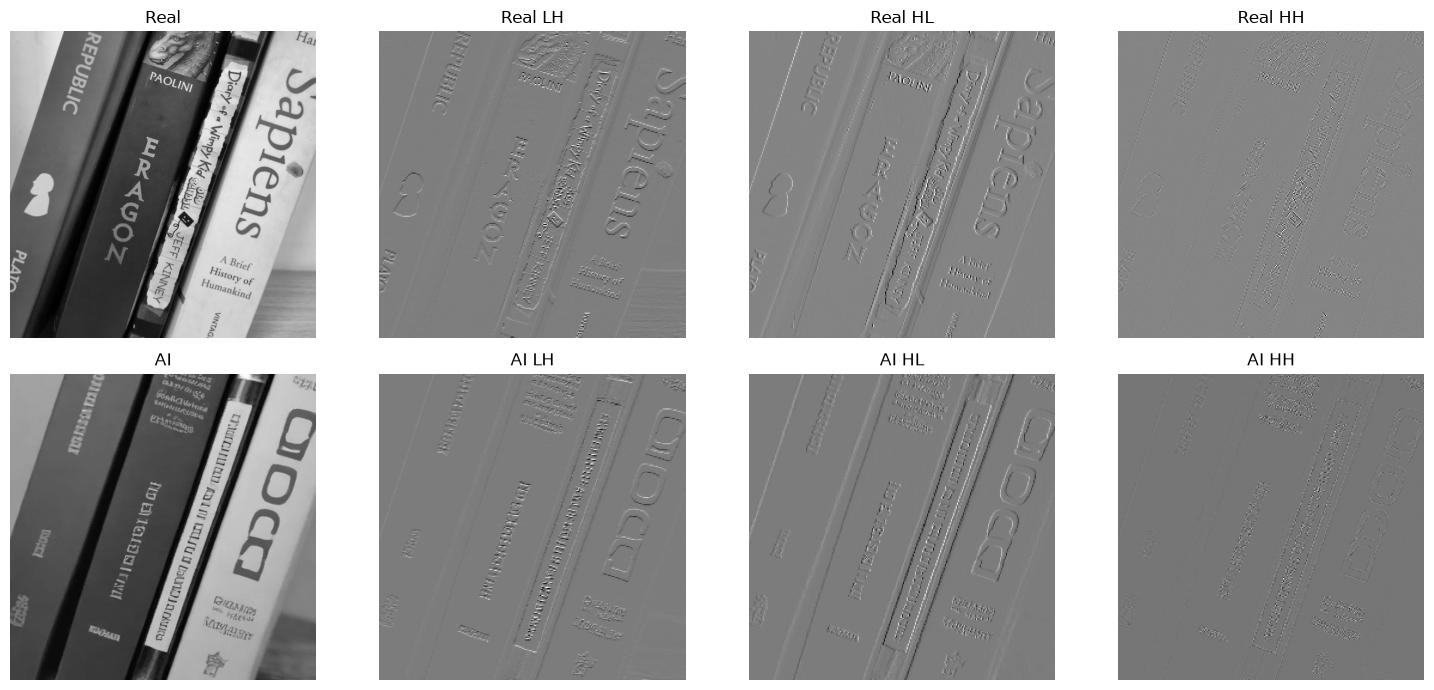

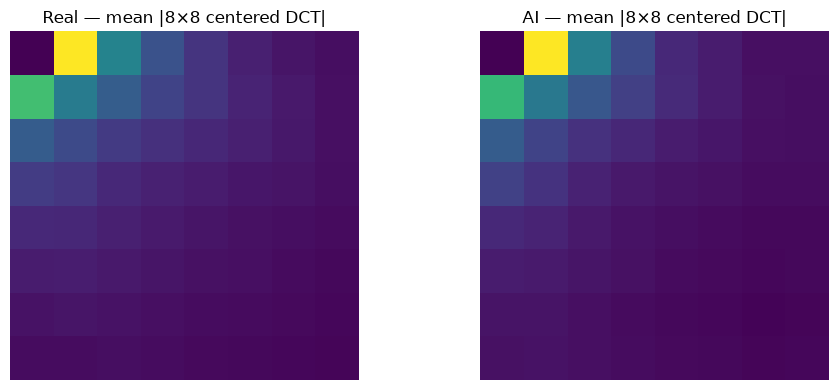

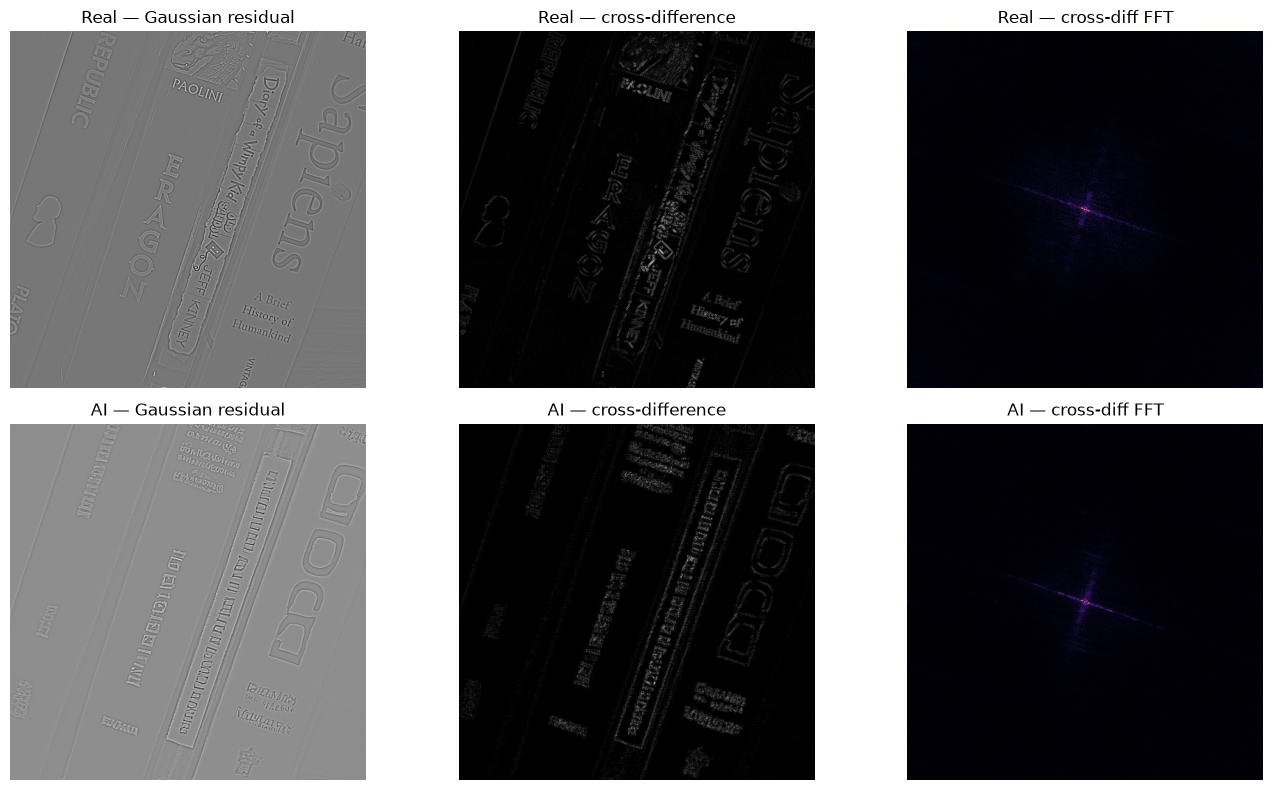

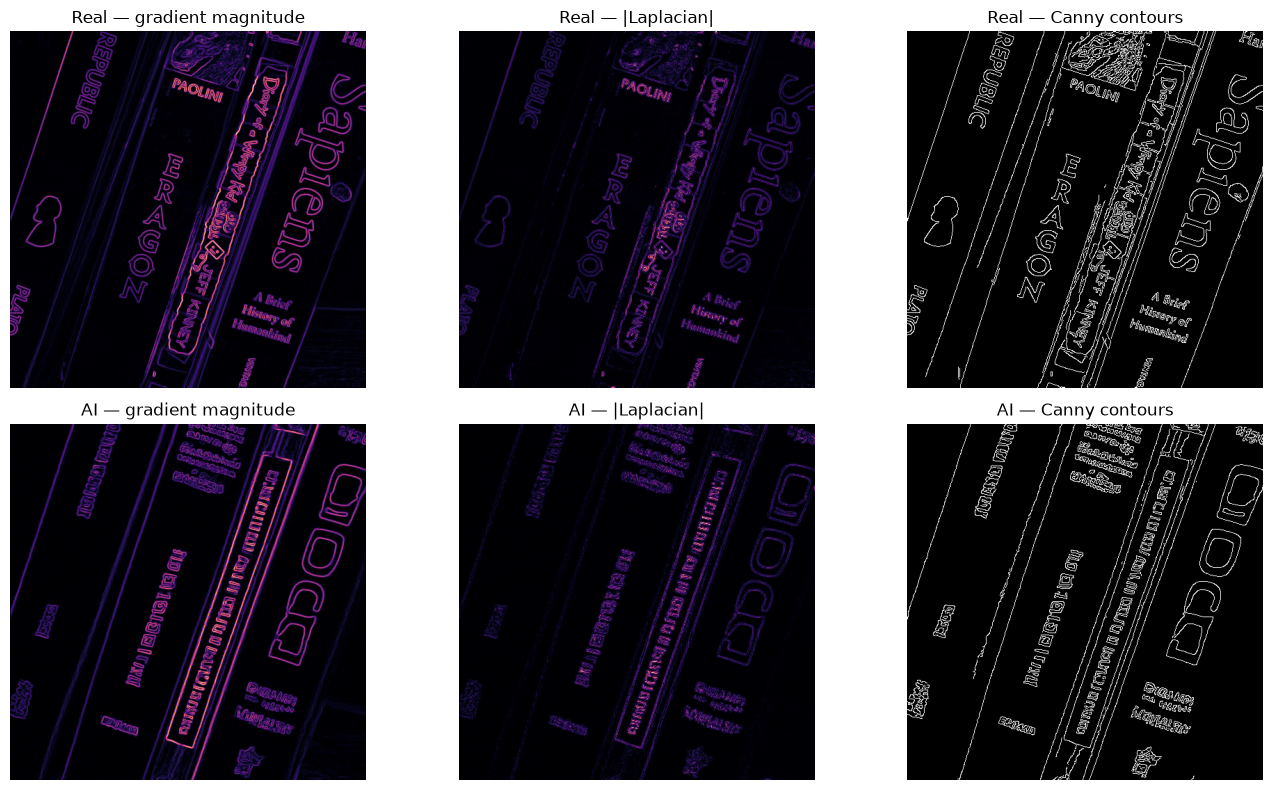

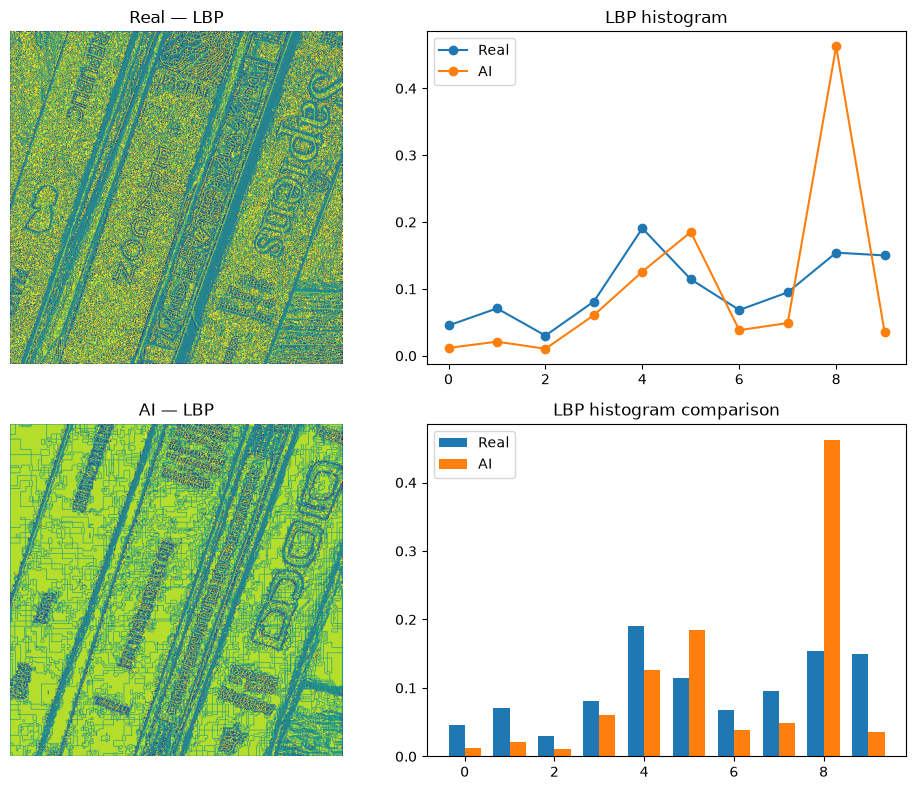

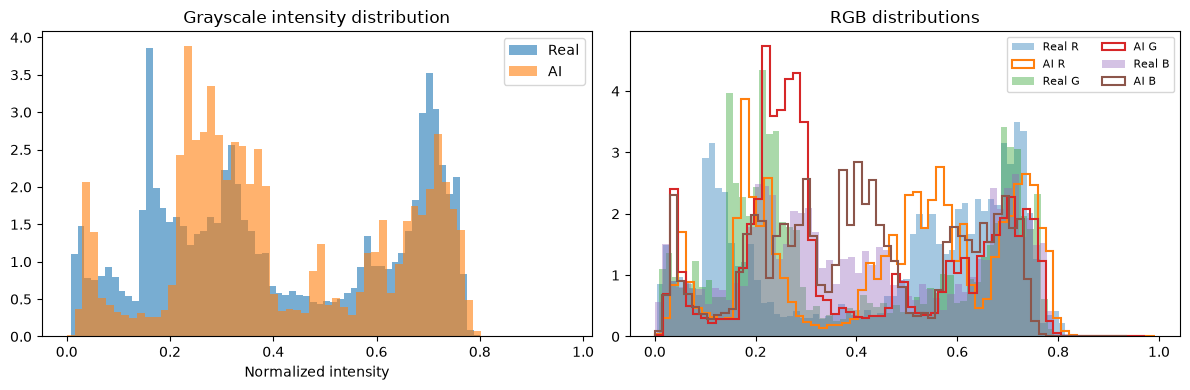

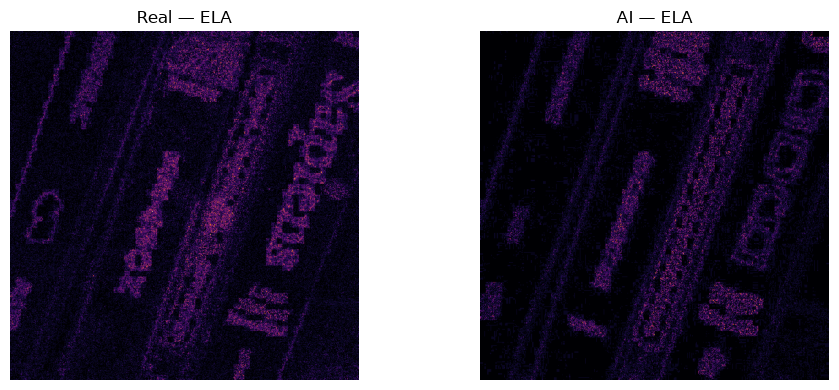

Finished 1/8: books
Finished 2/8: city
Finished 3/8: fabric
Finished 4/8: forest
Finished 5/8: fur
Finished 6/8: notes
Finished 7/8: p1
Finished 8/8: p2


,pair,real__low_freq_ratio,real__mid_freq_ratio,real__high_freq_ratio,real__spectral_centroid,real__LL3_energy,real__LL3_entropy,real__LH3_energy,real__LH3_absmean,real__LH3_entropy,...,ai__rgb_corr_rg,ai__rgb_corr_rb,ai__rgb_corr_gb,ai__hsv_saturation_mean,ai__hsv_value_mean,ai__hsv_saturation_std,ai__ela_mean,ai__ela_std,ai__ela_p95,ai__ela_max
0,books,0.973129,0.023810,0.003061,0.027456,13.948887,7.793007,0.052564,0.113457,5.273705,...,0.863481,0.708738,0.932417,0.328669,0.506460,0.218581,0.004239,0.005570,0.015686,0.070588
1,city,0.967974,0.027120,0.004907,0.023218,19.796944,6.906032,0.041739,0.093069,4.462185,...,0.993654,0.980011,0.994270,0.142042,0.596035,0.073172,0.003688,0.004714,0.011765,0.078431
2,fabric,0.856589,0.075239,0.068172,0.094356,13.158089,7.287775,0.005627,0.054589,6.514124,...,0.888347,0.610351,0.904002,0.253240,0.541513,0.067239,0.006124,0.006104,0.019608,0.062745
3,forest,0.971261,0.021958,0.006781,0.021035,13.349056,7.015172,0.051958,0.110968,4.927612,...,0.997307,0.988058,0.995329,0.192893,0.326765,0.137722,0.003869,0.005536,0.015686,0.074510
4,fur,0.649688,0.305238,0.045073,0.182217,22.852587,7.140827,0.049299,0.164657,6.835930,...,0.998788,0.997902,0.998700,0.076539,0.580226,0.024193,0.009539,0.007850,0.023529,0.070588


In [12]:
all_rows = []
cache = {}

for idx, (stem, rp, ap) in enumerate(pairs):
    r_rgb, a_rgb, rg, ag = load_pair(stem, rp, ap)

    # Run transforms
    Rfft, Afft = fft_features(rg), fft_features(ag)
    Rdwt, _ = dwt_features(rg)
    Adwt, _ = dwt_features(ag)
    Rdct, Adct = block_dct_features(rg), block_dct_features(ag)
    Rres, Ares = residual_features(r_rgb, rg), residual_features(a_rgb, ag)
    Redge, Aedge = edge_contour_features(rg), edge_contour_features(ag)
    Rlbp, Albp = lbp_features(rg), lbp_features(ag)
    Rglcm, _ = glcm_features(rg)
    Aglcm, _ = glcm_features(ag)
    Rcolor = intensity_color_features(r_rgb, rg)
    Acolor = intensity_color_features(a_rgb, ag)

    # ELA is deliberately calculated from the original files, not the resized arrays.
    Rela = ela_features_from_path(rp)
    Aela = ela_features_from_path(ap)

    cache[stem] = {
        "r_rgb": r_rgb, "a_rgb": a_rgb, "rg": rg, "ag": ag,
        "fft": (Rfft, Afft),
        "residual": (Rres, Ares),
    }

    def scalar_only(d):
        return {k: v for k, v in d.items() if np.isscalar(v) and not isinstance(v, (str, bytes))}

    rfeat, afeat = {}, {}
    for source in [Rfft, Rdwt, Rdct, Rres, Redge, Rlbp, Rglcm, Rcolor, Rela]:
        rfeat.update(scalar_only(source))
    for source in [Afft, Adwt, Adct, Ares, Aedge, Albp, Aglcm, Acolor, Aela]:
        afeat.update(scalar_only(source))

    row = {"pair": stem}
    row.update({f"real__{k}": v for k, v in rfeat.items()})
    row.update({f"ai__{k}": v for k, v in afeat.items()})
    all_rows.append(row)

    show = SHOW_ALL_VISUALS or idx == 0
    plot_fft_pair(stem, rg, ag, show=show)
    plot_dwt_pair(stem, rg, ag, show=show)
    plot_dct_pair(stem, rg, ag, show=show)
    plot_residual_pair(stem, r_rgb, a_rgb, rg, ag, show=show)
    plot_edges_pair(stem, rg, ag, show=show)
    plot_lbp_pair(stem, rg, ag, show=show)
    plot_intensity_pair(stem, r_rgb, a_rgb, rg, ag, show=show)
    plot_ela_pair(stem, Rela, Aela, show=show)

    print(f"Finished {idx+1}/{len(pairs)}: {stem}")

raw_df = pd.DataFrame(all_rows)
raw_df.to_csv(OUT_DIR / "all_scalar_features.csv", index=False)
raw_df.head()


# 12. Convert features into paired differences

For every scalar feature:

`delta = AI - Real`

and

`relative_delta = (AI - Real) / (|Real| + epsilon)`

The relative difference is useful for plotting features with different units, but it can become unstable when the real value is close to zero. The raw delta and paired effect size should therefore remain the primary statistics.


In [13]:
feature_names = sorted({
    c.split("__", 1)[1]
    for c in raw_df.columns
    if c.startswith("real__") or c.startswith("ai__")
})

# Keep only features present for both classes and remove any non-finite columns.
feature_names = [
    f for f in feature_names
    if f"real__{f}" in raw_df.columns and f"ai__{f}" in raw_df.columns
]

delta_rows = []
for _, row in raw_df.iterrows():
    out = {"pair": row["pair"]}
    for f in feature_names:
        r = float(row[f"real__{f}"])
        a = float(row[f"ai__{f}"])
        out[f"{f}__real"] = r
        out[f"{f}__ai"] = a
        out[f"{f}__delta"] = a - r
        # Relative delta is descriptive only; it is unstable when Real is near zero.
        out[f"{f}__relative_delta"] = (a - r) / (abs(r) + 1e-12)
    delta_rows.append(out)

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(OUT_DIR / "paired_feature_differences.csv", index=False)
delta_df.head()


,pair,HH1_absmean__real,HH1_absmean__ai,HH1_absmean__delta,HH1_absmean__relative_delta,HH1_energy__real,HH1_energy__ai,HH1_energy__delta,HH1_energy__relative_delta,HH1_entropy__real,...,synth_r_p8_d_mean__delta,synth_r_p8_d_mean__relative_delta,synth_r_p8_x_mean__real,synth_r_p8_x_mean__ai,synth_r_p8_x_mean__delta,synth_r_p8_x_mean__relative_delta,synth_r_p8_y_mean__real,synth_r_p8_y_mean__ai,synth_r_p8_y_mean__delta,synth_r_p8_y_mean__relative_delta
0,books,0.006714,0.003970,-0.002743,-0.408602,0.000271,0.000162,-0.000109,-0.401305,3.697218,...,0.006960,0.252184,0.045106,0.021723,-0.023383,-0.518406,0.042019,0.068454,0.026434,0.629104
1,city,0.006613,0.002147,-0.004466,-0.675330,0.000192,0.000067,-0.000125,-0.649641,3.985352,...,-0.019502,-0.492965,0.052828,0.027616,-0.025212,-0.477251,0.024632,0.075907,0.051275,2.081616
2,fabric,0.019231,0.005875,-0.013357,-0.694525,0.000872,0.000130,-0.000742,-0.850975,5.946820,...,0.003645,0.154595,0.065044,0.071181,0.006137,0.094356,0.072449,0.009129,-0.063320,-0.873993
3,forest,0.012506,0.004798,-0.007709,-0.616385,0.001025,0.000333,-0.000692,-0.675553,3.816390,...,0.018043,0.613159,0.084423,0.030357,-0.054066,-0.640414,0.031351,0.034732,0.003380,0.107826
4,fur,0.018567,0.019881,0.001314,0.070788,0.000679,0.000759,0.000080,0.118264,6.159068,...,0.036166,1.215683,0.070134,0.255785,0.185651,2.647106,0.091752,0.161883,0.070131,0.764361


# 13. Paired statistical analysis

Because there are only 8 pairs, statistical inference is necessarily exploratory.

The notebook uses an exact two-sided sign-flip test on paired differences, Cohen's paired effect `dz`, direction consistency, and Benjamini-Hochberg FDR correction. With n=8, p-values have limited resolution and should not be presented as proof of general AI-detection capability.

The statistics describe **this controlled set of pairs**. They do not estimate performance on unseen generators, cameras, compression pipelines or subjects.


In [14]:
def exact_signflip_pvalue(diffs):
    d = np.asarray(diffs, dtype=float)
    d = d[np.isfinite(d)]
    n = len(d)
    if n == 0:
        return np.nan
    if n > 20:
        raise ValueError("Exact sign-flip enumeration is intended for small n; use a Monte Carlo method for n > 20.")

    observed = abs(d.mean())
    signs = np.array(list(itertools.product([-1, 1], repeat=n)), dtype=float)
    means = (signs * d[None, :]).mean(axis=1)
    return float((np.abs(means) >= observed - 1e-15).mean())


def cohens_dz(diffs):
    d = np.asarray(diffs, dtype=float)
    d = d[np.isfinite(d)]
    if len(d) < 2 or np.std(d, ddof=1) == 0:
        return np.nan
    return float(d.mean() / np.std(d, ddof=1))


stats_rows = []
for f in feature_names:
    d = delta_df[f"{f}__delta"].to_numpy(float)
    d = d[np.isfinite(d)]
    if len(d) == 0:
        continue

    stats_rows.append({
        "feature": f,
        "n_pairs": len(d),
        "mean_delta_ai_minus_real": float(np.mean(d)),
        "median_delta": float(np.median(d)),
        "std_delta": float(np.std(d, ddof=1)) if len(d) > 1 else np.nan,
        "cohens_dz": cohens_dz(d),
        "direction_consistency_ai_gt_real": float(np.mean(d > 0)),
        "exact_signflip_p": exact_signflip_pvalue(d),
    })

stats_df = pd.DataFrame(stats_rows).sort_values("exact_signflip_p")


def bh_fdr(p):
    p = np.asarray(p, dtype=float)
    q = np.full_like(p, np.nan)
    valid = np.isfinite(p)
    pv = p[valid]
    if len(pv) == 0:
        return q
    order = np.argsort(pv)
    ranked = pv[order]
    m = len(ranked)
    adj = np.minimum.accumulate((ranked[::-1] * m / np.arange(m, 0, -1))[::-1])
    qv = np.empty(m)
    qv[order] = np.minimum(adj, 1)
    q[valid] = qv
    return q


stats_df["q_fdr"] = bh_fdr(stats_df["exact_signflip_p"].to_numpy())
stats_df = stats_df.sort_values(["q_fdr", "exact_signflip_p"])
stats_df.to_csv(OUT_DIR / "paired_statistics.csv", index=False)
stats_df.head(30)


,feature,n_pairs,mean_delta_ai_minus_real,median_delta,std_delta,cohens_dz,direction_consistency_ai_gt_real,exact_signflip_p,q_fdr
122,synth_r_p4_y_mean,8,0.273955,0.240319,0.211027,1.298200,1.000,0.007812,0.028125
24,LH3_absmean,8,-0.020773,-0.020773,0.012842,-1.617504,0.125,0.015625,0.028125
8,HH3_entropy,8,-0.630911,-0.697012,0.442349,-1.426272,0.125,0.015625,0.028125
35,crossdiff_fft_highfreq_ratio,8,-0.024845,-0.020185,0.023909,-1.039143,0.125,0.015625,0.028125
47,ela_std,8,-0.001253,-0.001491,0.000737,-1.700932,0.125,0.015625,0.028125
17,HL3_entropy,8,-0.433094,-0.472119,0.305520,-1.417565,0.125,0.015625,0.028125
40,dct_highfreq_ratio_mean,8,-0.080443,-0.090727,0.058600,-1.372749,0.125,0.015625,0.028125
83,lbp_dominant_bin,8,0.203310,0.269865,0.138163,1.471520,0.875,0.015625,0.028125
84,lbp_hist_entropy,8,-0.610101,-0.743539,0.417922,-1.459844,0.125,0.015625,0.028125
87,low_freq_ratio,8,0.044724,0.015886,0.063534,0.703944,0.875,0.015625,0.028125


# 14. Paired plots — the most useful figures

A paired plot is preferable to a bar chart of the two class means because your experiment is explicitly paired.

Each line connects the **same real photograph to its AI counterpart**.

The notebook also produces a feature heatmap of normalized paired changes.


In [15]:
# Select informative scalar features for presentation.
presentation_features = [
    "high_freq_ratio",
    "spectral_centroid",
    "detail_energy_ratio",
    "dct_highfreq_ratio_mean",
    "dct_dc_ratio_mean",
    "hp_std",
    "crossdiff_std",
    "crossdiff_fft_highfreq_ratio",
    "synth_r_p2_x_mean",
    "synth_r_p4_x_mean",
    "synth_r_p8_x_mean",
    "gradient_mean",
    "laplacian_absmean",
    "edge_density",
    "lbp_hist_entropy",
    "glcm_contrast_mean",
    "glcm_homogeneity_mean",
    "glcm_energy_mean",
    "intensity_entropy",
    "rgb_corr_rg",
    "rgb_corr_rb",
    "rgb_corr_gb",
    "ela_mean",
]

available = [f for f in presentation_features if f in feature_names]

for f in available:
    r = delta_df[f"{f}__real"].to_numpy(float)
    a = delta_df[f"{f}__ai"].to_numpy(float)

    fig, ax = plt.subplots(figsize=(7, 4))
    for i in range(len(r)):
        ax.plot([0, 1], [r[i], a[i]], marker="o", alpha=0.65)
    ax.set_xticks([0, 1], ["Real", "AI"])
    ax.set_title(f"Paired comparison — {f}")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    fig.savefig(OUT_DIR / f"paired_{f}.png", dpi=160, bbox_inches="tight")
    if SHOW_ALL_VISUALS:
        plt.show()
    plt.close(fig)

if available:
    heat = []
    labels = []
    for f in available:
        vals = delta_df[f"{f}__relative_delta"].to_numpy(float)
        heat.append(np.clip(vals, -2, 2))
        labels.append(f)

    heat = np.array(heat)
    fig, ax = plt.subplots(figsize=(12, max(5, 0.35 * len(labels))))
    im = ax.imshow(heat, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
    ax.set_yticks(np.arange(len(labels)), labels)
    ax.set_xticks(np.arange(len(delta_df)), delta_df["pair"], rotation=45, ha="right")
    ax.set_title("AI vs Real relative feature change (visualized, clipped to ±200%)")
    fig.colorbar(im, ax=ax, label="(AI − Real) / |Real|")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "paired_relative_change_heatmap.png", dpi=180, bbox_inches="tight")
    if SHOW_ALL_VISUALS:
        plt.show()
    plt.close(fig)


# 15. Aggregate report

This final table is intended for your project report.

Interpretation columns:
- **mean_delta**: average AI − Real shift;
- **Cohen dz**: standardized paired effect;
- **direction_consistency**: fraction of pairs where AI > Real;
- **q_fdr**: multiple-comparison-adjusted exploratory significance.

Do not rank features solely by p-value. With only 8 pairs and many correlated features, use the table to identify candidate forensic signals that deserve further testing on a larger, diverse dataset.


In [16]:
report_cols = [
    "feature",
    "mean_delta_ai_minus_real",
    "median_delta",
    "cohens_dz",
    "direction_consistency_ai_gt_real",
    "exact_signflip_p",
    "q_fdr",
]
report = stats_df[report_cols].copy()
report["abs_effect"] = report["cohens_dz"].abs()
report = report.sort_values("abs_effect", ascending=False)
report.to_csv(OUT_DIR / "final_feature_report.csv", index=False)
report.head(30)


,feature,mean_delta_ai_minus_real,median_delta,cohens_dz,direction_consistency_ai_gt_real,exact_signflip_p,q_fdr,abs_effect
85,lbp_mean_code,0.709331,0.766436,2.447808,1.000,0.007812,0.035156,2.447808
23,LH2_entropy,-0.961476,-0.971140,-2.363628,0.000,0.007812,0.089489,2.363628
14,HL2_entropy,-0.897255,-0.897852,-2.302579,0.000,0.007812,0.164062,2.302579
5,HH2_entropy,-1.313649,-1.368271,-2.299624,0.000,0.007812,0.492188,2.299624
118,synth_r_p2_x_mean,0.128064,0.117195,1.976933,1.000,0.007812,0.037861,1.976933
98,synth_b_p2_x_mean,0.127869,0.116218,1.936842,1.000,0.007812,0.028952,1.936842
11,HL1_entropy,-1.135583,-1.083099,-1.880478,0.000,0.007812,0.140625,1.880478
46,ela_p95,-0.003922,-0.003922,-1.870829,0.000,0.015625,0.028125,1.870829
18,LH1_absmean,-0.006025,-0.006432,-1.841586,0.000,0.007812,0.123047,1.841586
108,synth_g_p2_x_mean,0.118991,0.104034,1.832956,1.000,0.007812,0.044744,1.832956


## References / implementation basis

- Bammey, *Synthbuster: Towards Detection of Diffusion Model Generated Images*, IEEE Open Journal of Signal Processing. The method uses a cross-difference high-pass residual followed by Fourier analysis of periodic artifacts.
- SciPy current FFT/DCT APIs.
- PyWavelets current 2-D multilevel DWT APIs.
- scikit-image current GLCM/LBP/entropy APIs.

**Scope limitation:** this notebook analyzes your eight paired images. It does not establish a detector that generalizes to arbitrary generators, cameras, compression pipelines or editing operations.
